In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load the dataset with the correct separator
df = pd.read_csv('data/student-mat.csv', sep=';')

print("Data Loaded Successfully!")
print(f"Dataset contains {df.shape[0]} students and {df.shape[1]} features.")
df.head()

Data Loaded Successfully!
Dataset contains 395 students and 33 features.


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


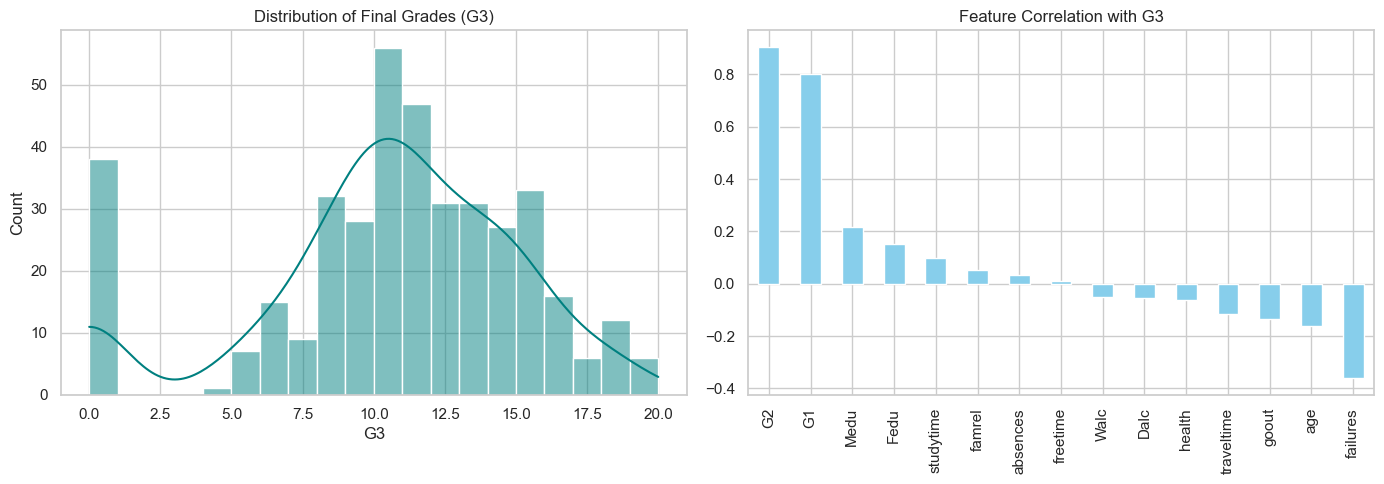

In [18]:
# Setting up the visual style
sns.set(style="whitegrid")

# Create a figure with two subplots
plt.figure(figsize=(14, 5))

# Plot 1: Distribution of Final Grades
plt.subplot(1, 2, 1)
sns.histplot(df['G3'], bins=20, kde=True, color='teal')
plt.title('Distribution of Final Grades (G3)')

# Plot 2: Correlation of numeric features with the final grade
plt.subplot(1, 2, 2)
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['G3'].sort_values(ascending=False)
correlations.drop('G3').plot(kind='bar', color='skyblue')
plt.title('Feature Correlation with G3')

plt.tight_layout()
plt.show()

In [19]:
# 1. Label Encoding for Binary Columns (2 choices)
le = LabelEncoder()
binary_cols = ['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 
               'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 2. One-Hot Encoding for Nominal Columns (3+ choices)
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_final = pd.get_dummies(df, columns=nominal_cols)

print(f"Preprocessing Complete. New feature count: {df_final.shape[1]}")

Preprocessing Complete. New feature count: 46


In [20]:
# Define Features (X) and Target (y)
X = df_final.drop('G3', axis=1)
y = df_final['G3']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Model Training Results:")
print(f"- Mean Absolute Error: {mae:.2f} points")
print(f"- Accuracy (R2 Score): {r2:.2f}")

Model Training Results:
- Mean Absolute Error: 1.16 points
- Accuracy (R2 Score): 0.82


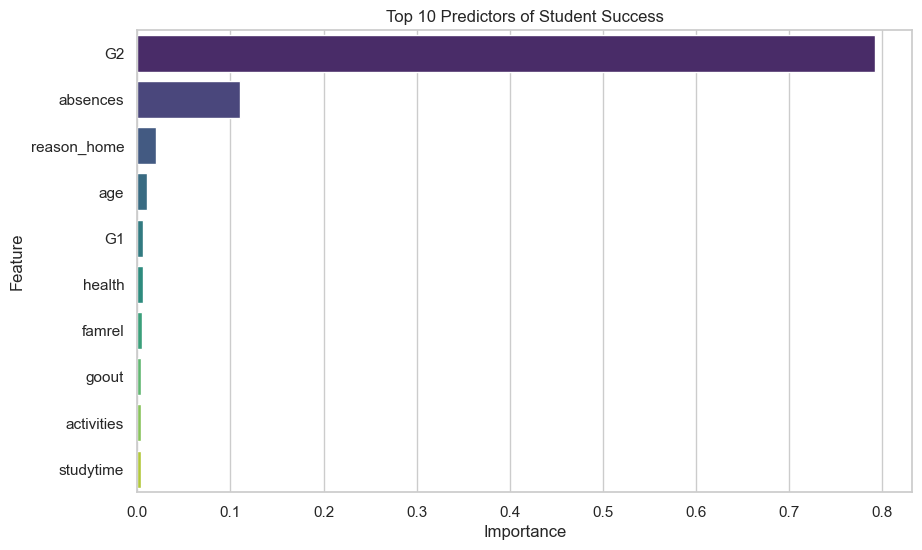

In [21]:
# Get the most important factors
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))

# Fix: Added 'hue' and 'legend=False' to remove the FutureWarning
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feature_importance_df.head(10), 
    palette='viridis', 
    hue='Feature', 
    legend=False
)

plt.title('Top 10 Predictors of Student Success')
plt.show()

In [22]:
def predict_student_grade(input_dict):
    """
    Takes a dictionary of user inputs, aligns it with the model's 
    expected features, and returns a predicted grade.
    """
    # 1. Create a DataFrame with a single row of zeros, matching our training features
    input_df = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # 2. Fill in the values we got from the user
    for key, value in input_dict.items():
        if key in input_df.columns:
            input_df.at[0, key] = value
        else:
            # This handles one-hot encoded columns (like Mjob_teacher)
            # if the user input matches a specific category
            col_name = f"{key}_{value}"
            if col_name in input_df.columns:
                input_df.at[0, col_name] = 1

    # 3. Use the trained model to predict
    prediction = model.predict(input_df)
    
    # Return the result rounded to 2 decimal places
    return round(prediction[0], 2)

print("Prediction Engine is ready.")

Prediction Engine is ready.


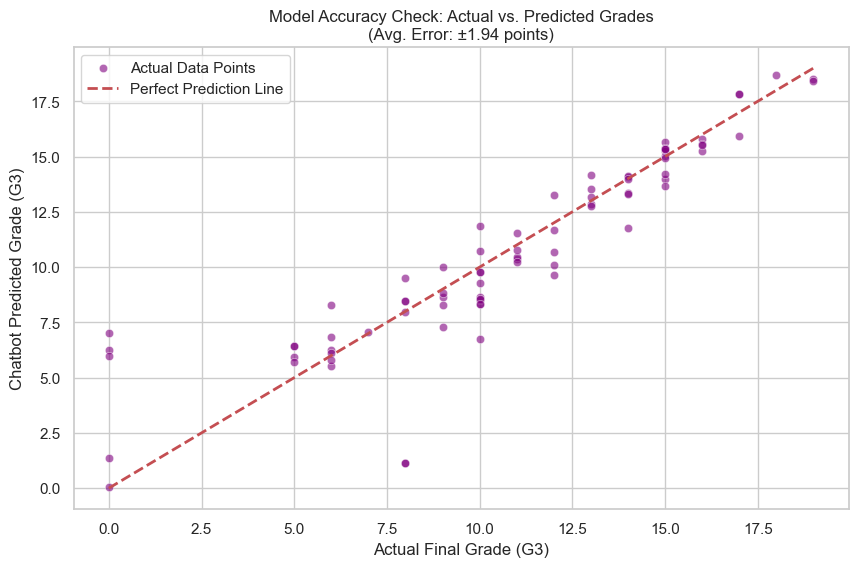

✅ Accuracy Validation Complete.
👉 On average, your chatbot's prediction is off by only 1.94 points.


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# 1. Generate predictions for the entire test set
y_pred = model.predict(X_test)

# 2. Calculate RMSE (Root Mean Squared Error) 
# This tells us, on average, how many "grade points" the bot is off by.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# 3. Create the Visualization
plt.figure(figsize=(10, 6))

# Plotting the Actual vs Predicted values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple', label='Actual Data Points')

# Plotting the "Perfect Prediction" line
# If the model were 100% accurate, all dots would be on this line.
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')

plt.title(f'Model Accuracy Check: Actual vs. Predicted Grades\n(Avg. Error: ±{rmse:.2f} points)')
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Chatbot Predicted Grade (G3)')
plt.legend()
plt.show()

print(f"✅ Accuracy Validation Complete.")
print(f"👉 On average, your chatbot's prediction is off by only {rmse:.2f} points.")

In [24]:
from sklearn.model_selection import cross_val_score

# We split the entire dataset into 5 different parts (Folds)
# The model trains on 4 parts and tests on 1, repeating this 5 times.
cv_scores = cross_val_score(model, X, y, cv=5)

print("--- 🛡️ K-Fold Cross-Validation Results ---")
print(f"Scores for each fold: {cv_scores}")
print(f"Average Accuracy (R2): {cv_scores.mean():.2f}")
print(f"Model Stability (Std Dev): {cv_scores.std():.2f}")

# Insight: If the Standard Deviation is low (e.g., < 0.05), your model is very reliable.

--- 🛡️ K-Fold Cross-Validation Results ---
Scores for each fold: [0.76692909 0.8096258  0.86303397 0.86432229 0.81064484]
Average Accuracy (R2): 0.82
Model Stability (Std Dev): 0.04


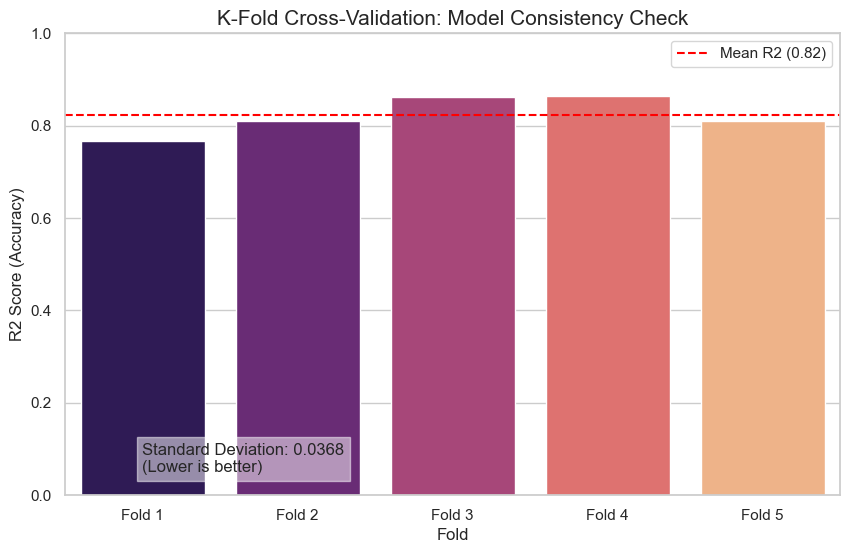

In [25]:

# 1. Create a DataFrame for plotting
fold_numbers = [f"Fold {i+1}" for i in range(len(cv_scores))]
cv_df = pd.DataFrame({'Fold': fold_numbers, 'R2 Score': cv_scores})

# 2. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Fold', y='R2 Score', data=cv_df, hue='Fold', palette='magma', legend=False)

# 3. Add a horizontal line for the Mean Score
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean R2 ({cv_scores.mean():.2f})')

# 4. Add labels and title
plt.title('K-Fold Cross-Validation: Model Consistency Check', fontsize=15)
plt.ylabel('R2 Score (Accuracy)')
plt.ylim(0, 1.0) # Scale from 0 to 1 for clarity

# Annotate the Stability (Standard Deviation)
plt.text(0, 0.05, f"Standard Deviation: {cv_scores.std():.4f}\n(Lower is better)", 
         bbox=dict(facecolor='white', alpha=0.5))

plt.legend()
plt.show()

In [26]:
import pickle

# 1. Save the model to a file
with open('student_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# 2. Save the column names (very important to keep features in order)
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(X.columns.tolist(), file)

print("✅ Model and Column names exported successfully as .pkl files!")

✅ Model and Column names exported successfully as .pkl files!


In [ ]:
def start_edu_chatbot():
    print("==================================================")
    print("   🎓  WELCOME TO THE EDU-ANALYTICS BOT  🎓   ")
    print("==================================================")
    print("I use Machine Learning to predict your final Math score.")
    print("Please answer a few questions about your academic habits.\n")
    
    try:
        # 1. Collect user inputs (Focusing on high-impact features)
        g1 = float(input("👉 Enter your Grade 1 score (0-20): "))
        g2 = float(input("👉 Enter your Grade 2 score (0-20): "))
        absences = int(input("👉 How many classes have you missed? (0-93): "))
        failures = int(input("👉 Number of past class failures (0-3): "))
        study_time = int(input("👉 Weekly study time (1: <2h, 2: 2-5h, 3: 5-10h, 4: >10h): "))
        go_out = int(input("👉 How often do you go out with friends? (1: Low to 5: High): "))

        # 2. Prepare the data for the model
        # We create a template based on the columns the model was trained on
        input_data = pd.DataFrame(0, index=[0], columns=X.columns)
        
        # Fill in the user's answers
        input_data.at[0, 'G1'] = g1
        input_data.at[0, 'G2'] = g2
        input_data.at[0, 'absences'] = absences
        input_data.at[0, 'failures'] = failures
        input_data.at[0, 'studytime'] = study_time
        input_data.at[0, 'goout'] = go_out

        # 3. Generate Prediction
        prediction = model.predict(input_data)[0]
        final_score = round(prediction, 2)

        # 4. Display Results & Advice
        print("\n" + "="*40)
        print(f"📊  PREDICTED FINAL GRADE (G3): {final_score} / 20")
        print("="*40)

        # Advice Logic
        if final_score >= 15:
            print("🌟 Result: EXCELLENT. You are a top-performing student!")
        elif final_score >= 10:
            print("📈 Result: PASSING. You are on the right track.")
        else:
            print("⚠️ Result: AT-RISK. You are currently predicted to fail.")

        print("\n--- 💡 PERSONALIZED ADVICE ---")
        if absences > 10:
            print("- Your attendance is a major risk factor. Try to attend more lectures.")
        if study_time < 2:
            print("- Small increases in study time (even 1 hour) can significantly boost your G3.")
        if failures > 0:
            print("- Don't let past failures discourage you; focus on consistent G2 performance.")
        if final_score >= 15:
            print("- Maintain your current balance! Your G1 and G2 scores are very strong.")

    except ValueError:
        print("\n❌ Error: Please enter valid numerical values.")

# Run the bot
start_edu_chatbot()

   🎓  WELCOME TO THE EDU-ANALYTICS BOT  🎓   
I use Machine Learning to predict your final Math score.
Please answer a few questions about your academic habits.

